In [1]:
def get_config(file: str):
    import yaml

    lines = []
    with open(file, "r") as f:
        
        while True:
            line = f.readline()
            
            is_config_handled = False
            if line.strip().endswith("Config:"):
                while True:
                    l = f.readline()
                    l = l.strip("\n")
                    if len(l) != 0:
                        lines.append(l)
                    else:
                        break
                is_config_handled = True

            if is_config_handled:
                break
    return yaml.safe_load("\n".join(lines))

def get_perf(file: str):

    encoding = 0
    inference = 0
    msa_searching = 0
    
    with open(file, "r") as f:
        
        lines = f.readlines()
        for line in lines:

            if "Function 'encode' executed" in line.strip():
                encoding = float(line.strip().split()[-2])

            if "Function 'predict' executed" in line.strip():
                inference = float(line.strip().split()[-2])

    return {
        "encoding": round(encoding / 60, 2),
        "inference": round(inference / 60, 2),
        "msa searching": msa_searching / 60,
    }

In [2]:
from pathlib import Path

directory = Path('../tmp')
files = []
for file in directory.rglob('*'):
    if file.is_file() and file.name.endswith(".log"):
        files.append(file)

In [3]:
records = []

# from {PROJECT_DIR}/model/test/analysis/compare.ipynb
f1_scores = {
    ("svm", "esm2-150M"): 0.7893,
    ("ag", "esm2-150M"): 0.7909,
    ("ag", "esm2-650M"): 0.7918,
    ("svm", "prott5-xl"): 0.8012,
    ("svm", "esm2-3B"): 0.8014,
    ("svm", "ankh-base"): 0.8048,
    ("svm", "ankh-large"): 0.8097,
}

for i in files:
    cfg = get_config(i)
    perf = get_perf(i)

    model = cfg['model']['name']
    plm = cfg['plm']['name']
    records.append({
        "model": model,
        "plm": plm,
        **perf,
        "f1-score": f1_scores[(model, plm)]
    })

records.append({
    "model": "ag",
    "plm": "MetalNet2", 
    "f1-score": 0.7577, 
    "msa searching": 10000, # estimated, 1 min for 1 seq
    "encoding": 5.47, # borrowed from ag_esm2-650M
    "inference": 6.60, # borrowed from ag_esm2-650M
})

import pandas as pd
df = pd.DataFrame(records)
df = df.sort_values(by=['model'])
df['total'] = df['msa searching'] + df['encoding'] + df['inference']
df

,model,plm,encoding,inference,msa searching,f1-score,total
3,ag,esm2-650M,5.47,6.60,0.0,0.7918,12.07
4,ag,esm2-150M,2.03,3.55,0.0,0.7909,5.58
6,ag,MetalNet2,5.47,6.60,10000.0,0.7577,10012.07
0,svm,ankh-large,8.21,0.51,0.0,0.8097,8.72
1,svm,esm2-3B,16.89,0.51,0.0,0.8014,17.40
2,svm,prott5-xl,7.50,0.37,0.0,0.8012,7.87
5,svm,ankh-base,4.38,0.31,0.0,0.8048,4.69


<Figure size 240x300 with 0 Axes>

([<matplotlib.axis.XTick at 0x7d79cb13cc10>,
 [Text(0.75, 0, '0.75'),
  Text(0.77, 0, '0.77'),
  Text(0.79, 0, '0.79'),
  Text(0.81, 0, '0.81'),
  Text(0.83, 0, '0.83')])

([<matplotlib.axis.YTick at 0x7d79d3375e10>,
 [Text(0, -14, '−14'),
  Text(0, -12, '−12'),
  Text(0, -10, '−10'),
  Text(0, -8, '−8'),
  Text(0, -6, '−6'),
  Text(0, -4, '−4'),
  Text(0, -2, '−2')])

Text(0.7908, -3.593353770980297, 'esm2-650M')

Text(0.7899, -2.4802651220544627, 'esm2-150M')

...

Text(0.8004, -4.121015400961366, 'esm2-3B')

Text(0.8002, -2.9763636357327616, 'prott5-xl')

Text(0.8038, -2.229587922740652, 'ankh-base')

Text(0.5, 0, 'F1-score')

Text(0, 0.5, 'Time cost for 10K sequences, $-log_2$(min)')

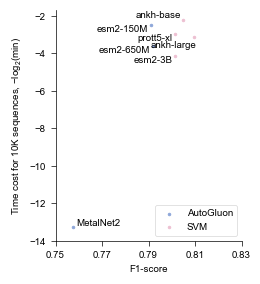

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

plt.figure(figsize=(2.4, 3.0))
x = list(df['f1-score'])
y = list(-np.log2(df['total']))
labels = list(df['plm'])
models = list(df['model'])
plt.scatter(x[:3], y[:3], label="AutoGluon", s=4)
plt.scatter(x[3:], y[3:], label="SVM", s=4)
plt.xticks([i / 100 for i in range(75, 84, 2)])
plt.yticks([i for i in range(-14, 0, 2)])

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, label in enumerate(labels):
    if label == "MetalNet2":
        plt.text(x[i] + 0.001, y[i], label, fontsize=7, ha='left', va='bottom')
    elif label == "ankh-base":
        plt.text(x[i] - 0.001, y[i], label, fontsize=7, ha='right', va='bottom')
    elif label == "ankh-large":
        plt.text(x[i] + 0.001, y[i] - 0.7, label, fontsize=7, ha='right', va='bottom')
    else:
        plt.text(x[i] - 0.001, y[i], label, fontsize=7, ha='right', va='top')
plt.legend()
plt.xlabel('F1-score')
plt.ylabel(r'Time cost for 10K sequences, $-log_2$(min)')

plt.savefig("./fig/afdb_10k_runtime_comparison.pdf", bbox_inches="tight", transparent=True)

<BarContainer object of 2 artists>

<BarContainer object of 2 artists>

<BarContainer object of 2 artists>

<BarContainer object of 2 artists>

<BarContainer object of 2 artists>

...

/tmp/ipykernel_548875/1706053341.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([str(i) for i in range(0, 20, 5)])


[Text(0, 0.0, '0'),
 Text(0, 5000.0, '5'),
 Text(0, 10000.0, '10'),
 Text(0, 15000.0, '15')]

(0.0, 20.0)

[Text(0, 0, 'MetalNet2'), Text(1, 0, 'ankh-base')]

Text(-0.2, 0.5, 'Time cost for 10K sequences (min)')

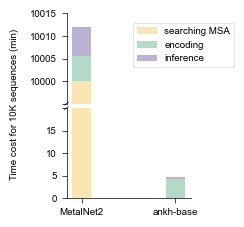

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

# from cycler import cycler
# orig = plt.rcParams['axes.prop_cycle'].by_key()['color']
# shifted = orig[2:] + orig[:2]
# plt.rcParams['axes.prop_cycle'] = cycler(color=shifted)

df_ = df.iloc[[2, 6]]
labels = df_['plm']
data1 = list(df_['msa searching'])
data2 = list(df_['encoding'])
data3 = list(df_['inference'])

x = np.arange(len(labels))
width = 0.2

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.05}, figsize=(1.6, 2.4))

ax1.bar(x, data1, label='searching MSA', width=width)
ax1.bar(x, data2, bottom=data1, label='encoding', width=width)
ax1.bar(x, data3, bottom=np.array(data1) + np.array(data2), label='inference', width=width)

ax2.bar(x, data1, label='searching MSA', width=width)
ax2.bar(x, data2, bottom=data1, label='encoding', width=width)
ax2.bar(x, data3, bottom=np.array(data1) + np.array(data2), label='inference', width=width)


ax1.set_yticklabels([""] + [str(i) for i in range(10000, 100015, 5)])
ax1.set_ylim(9995, 10015)
ax2.set_yticklabels([str(i) for i in range(0, 20, 5)])
ax2.set_ylim(0, 20)

ax1.spines['bottom'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(labeltop=False, bottom=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.xaxis.tick_bottom()

d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend(bbox_to_anchor=(0.5, 2))

fig.text(-0.2, 0.5, 'Time cost for 10K sequences (min)', ha='center', va='center', rotation='vertical')

plt.savefig("./fig/afdb_10k_runtime_comparison_detail.pdf", bbox_inches="tight", transparent=True)